# 01 — Preprocessing: clean, join, and prepare the raw data

Everything between "raw downloaded files" and "a clean joined dataset ready for exploration" lives in this one notebook, in three stages:

1. **Clean Price Paid** — filter to Sefton, drop non-market sales, fix types.
2. **Clean EPC** — load, filter, normalise addresses.
3. **Join them** — the hardest part (plan Part 4): neither dataset shares a key, so this matches by UPRN where possible and by address otherwise, and measures how well that worked.

Each stage reads its own inputs and writes its own output to `data/interim/`, so it can still be run and debugged as a standalone step even though it now lives in one file.

## Stage 1 — Price Paid

# 01 — Price Paid: clean and filter to Sefton

Phase 1 thin slice (plan Part 8). Loads the yearly Price Paid CSVs with
DuckDB (no header row in the source files — schema supplied explicitly),
filters to Sefton, drops category B, and applies the cleaning rules from
plan Part 3.

Never load the full multi-year file into pandas — DuckDB filters at read
time so this stays fast and low-memory even once we widen to all six LAs.


In [1]:
import sys
sys.path.insert(0, "..")
from src.config import (
    DATA_RAW, DATA_INTERIM, PPD_COLUMNS, LOCAL_AUTHORITIES, EPC_CSV,
)
import duckdb
import pandas as pd

AUTHORITIES = list(LOCAL_AUTHORITIES)
print(f"Scope: {len(AUTHORITIES)} local authorities")
print(", ".join(AUTHORITIES))

ppd_dir = DATA_RAW / "price_paid"
files = sorted(ppd_dir.glob("pp-*.csv"))
print(f"\n{len(files)} yearly Price Paid files found")
assert files, "Run notebook 00 first to download Price Paid data."
assert EPC_CSV.exists(), f"{EPC_CSV} not found - see notebook 00."


Scope: 6 local authorities
SEFTON, LIVERPOOL, KNOWSLEY, WIRRAL, ST HELENS, WEST LANCASHIRE

19 yearly Price Paid files found


## Load with an explicit schema

The CSVs have no header row. `read_csv` gets the column names and types
directly rather than inferring — inference on a quoted, comma-heavy address
field is exactly the kind of thing that goes wrong silently.


In [2]:
con = duckdb.connect()

col_list = ", ".join(f'"{c}"' for c in PPD_COLUMNS)
glob_pattern = str(ppd_dir / "pp-*.csv")

# All columns arrive as VARCHAR; cast price/date explicitly afterwards.
# union_by_name handles the monthly-file schema (17 cols incl. record_status)
# vs yearly-file schema (16 cols) transparently if we ever mix them in.
query = f'''
    SELECT * FROM read_csv(
        '{glob_pattern}',
        header = false,
        columns = {{
            {", ".join(f"'{c}': 'VARCHAR'" for c in PPD_COLUMNS[:14])},
            'ppd_category_type': 'VARCHAR',
            'record_status': 'VARCHAR'
        }},
        ignore_errors = true,
        union_by_name = true
    )
'''
raw = con.execute(query).df()
print(f"{len(raw):,} rows loaded across {len(files)} files")
raw.head()


16,471,705 rows loaded across 19 files


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status
0,{A3A8F9D7-8978-43C2-8D46-6DEEE7FD19FE},221000,2008-07-31 00:00,DH4 4SQ,S,N,F,6,NaN,COALEY LANE,HOUGHTON LE SPRING,HOUGHTON LE SPRING,SUNDERLAND,TYNE AND WEAR,A,A
1,{F30DF059-9791-43B0-9C5C-6DEEE85570B9},163500,2008-08-19 00:00,MK13 7QJ,S,N,F,7,NaN,LUNDHOLME,HEELANDS,MILTON KEYNES,MILTON KEYNES,MILTON KEYNES,A,A
2,{259E67B4-8439-472D-9D6B-6DEF02780C52},272500,2008-08-27 00:00,N4 2BB,F,N,L,145,FLAT 4,QUEENS DRIVE,LONDON,LONDON,HACKNEY,GREATER LONDON,A,A
3,{2A80BBDA-DFA7-4DAE-9DD3-66CFDA423517},2122500,2008-01-09 00:00,SL6 9SD,D,N,F,WESTWARD HOUSE,NaN,BERRIES ROAD,COOKHAM,MAIDENHEAD,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,A
4,{6D68437C-8FB9-41E4-A988-66CFEA64E0A4},158000,2008-01-04 00:00,DE4 3LH,T,N,F,253,NaN,SMEDLEY STREET,MATLOCK,MATLOCK,DERBYSHIRE DALES,DERBYSHIRE,A,A


## Filter and clean — plan Part 3

- Sefton only (Phase 1 thin slice)
- **Drop PPD category B** — repossessions, transfers, portfolio sales, not
  open-market prices (~5% of rows per the handover)
- Drop property_type 'O' (Other — park homes, non-standard, too heterogeneous
  for a hedonic model on floor area)
- Cast price to numeric, date to datetime
- Drop price outliers: <£20k or >£2m
- Dedupe on transaction_id


In [3]:
df = raw.copy()
df = df[df["district"].str.upper().isin(AUTHORITIES)]
print(f"After LA filter ({len(AUTHORITIES)} authorities): {len(df):,} rows")
print(df["district"].value_counts().to_string())
print()

before = len(df)
df = df[df["ppd_category_type"] == "A"]
print(f"Dropped category B: {before - len(df):,} rows ({(before - len(df)) / before:.1%})")

before = len(df)
df = df[df["property_type"] != "O"]
print(f"Dropped property_type 'O': {before - len(df):,} rows")

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["date_of_transfer"] = pd.to_datetime(df["date_of_transfer"], errors="coerce")
df = df.dropna(subset=["price", "date_of_transfer", "postcode"])

before = len(df)
df = df[(df["price"] >= 20_000) & (df["price"] <= 2_000_000)]
print(f"Dropped price outliers (<£20k or >£2m): {before - len(df):,} rows")

before = len(df)
df = df.drop_duplicates(subset=["transaction_id"])
print(f"Dropped duplicate transaction_ids: {before - len(df):,} rows")

df["postcode"] = df["postcode"].str.upper().str.strip()
print(f"\nFinal: {len(df):,} clean category-A transactions, "
      f"{df['date_of_transfer'].min().date()} to {df['date_of_transfer'].max().date()}")


After LA filter (6 authorities): 390,779 rows
district
LIVERPOOL          123296
WIRRAL              86795
SEFTON              73984
ST HELENS           44866
KNOWSLEY            33035
WEST LANCASHIRE     28803

Dropped category B: 61,797 rows (15.8%)
Dropped property_type 'O': 0 rows


Dropped price outliers (<£20k or >£2m): 185 rows
Dropped duplicate transaction_ids: 0 rows

Final: 328,750 clean category-A transactions, 2008-01-01 to 2026-06-30


## Sanity checks

Quick distributional look before this becomes an input to anything else.


In [4]:
print(df["property_type"].value_counts())
print()
print(df["duration"].value_counts())
print()
print(df["price"].describe())


property_type
S    126441
T     97687
D     56912
F     47710
Name: count, dtype: int64

duration
F    231493
L     97257
Name: count, dtype: int64

count    3.287500e+05
mean     1.819577e+05
std      1.227191e+05
min      2.000000e+04
25%      1.059950e+05
50%      1.530000e+05
75%      2.220000e+05
max      2.000000e+06
Name: price, dtype: float64


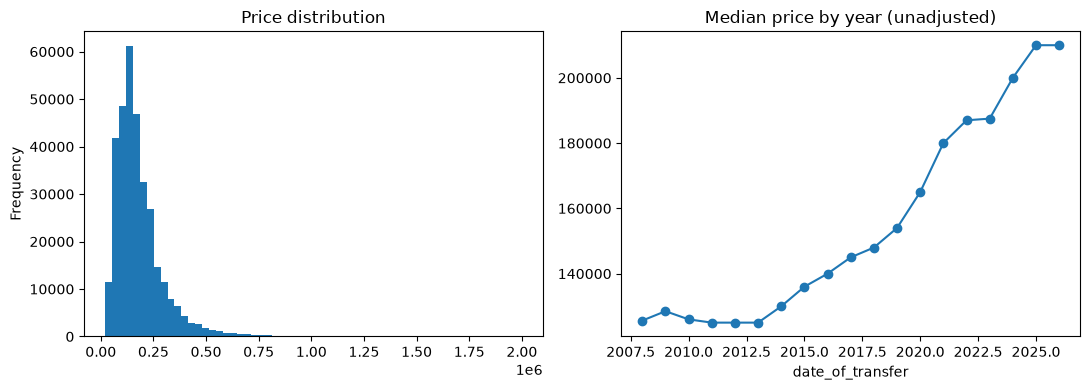

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["price"].plot(kind="hist", bins=60, ax=axes[0], title="Price distribution")
df.groupby(df["date_of_transfer"].dt.year)["price"].median().plot(ax=axes[1], marker="o", title="Median price by year (unadjusted)")
plt.tight_layout()
plt.show()


## Save

Output feeds notebook 03 (address join).


In [6]:
out = DATA_INTERIM / "price_paid_clean.parquet"
df.to_parquet(out, index=False)
print(f"Saved {len(df):,} rows to {out}")


Saved 328,750 rows to C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\data\interim\price_paid_clean.parquet


## Stage 2 — EPC

# 02 — EPC: clean and prepare (Sefton, thin slice)

Requires `data/raw/epc/sefton_certificates.csv` — a Sefton-filtered export
from the "Download files" flow at
<https://get-energy-performance-data.communities.gov.uk/> (GOV.UK One Login,
filter to Sefton before downloading). Same schema as the classic EPC bulk
CSV: snake_case columns, header row present.

This notebook does three things (plan Part 2-3):
1. Keep only the fields we're actually using in Phase 1 — size, rooms, type,
   age band. Condition descriptors and the `(assumed)` filter are parked
   (plan Part 8) until the simple model is measured.
2. **Don't collapse to one row per property yet** — which certificate is
   "correct" depends on *which sale* it's being matched to (use the one
   current at that sale date, plan Part 5 leakage control #1). That
   happens in notebook 04 once the join exists.
3. Clean the address for the join in notebook 03.


In [7]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_RAW, DATA_INTERIM, EPC_CSV, EPC_LABEL_TO_DISTRICT
import pandas as pd
import re

print(f"Reading combined EPC export: {EPC_CSV.name} "
      f"({EPC_CSV.stat().st_size / 1e6:,.0f} MB)")


Reading combined EPC export: north_west_certificates.csv (730 MB)


## Load and select columns

Full EPC exports carry 90+ columns (every SAP element, cost breakdown,
etc). Phase 1 keeps only what Part 2 of the plan actually uses; everything
else stays in the raw file, parked for later.


In [8]:
KEEP_COLS = [
    "certificate_number",
    "uprn", "uprn_source",
    "address1", "address2", "address3",
    "postcode",
    "local_authority_label",
    "property_type",
    "built_form",
    "total_floor_area",
    "number_habitable_rooms",
    "number_heated_rooms",
    "extension_count",
    "construction_age_band",
    "tenure",
    "inspection_date",
    "lodgement_date",
    "transaction_type",
]

# 730 MB on disk is mostly the 90+ columns we don't want; reading only the
# 19 we do keeps this manageable.
raw = pd.read_csv(EPC_CSV, usecols=KEEP_COLS, dtype=str, low_memory=False)

# Map the EPC's own authority spelling onto the Price Paid district names
# we filter and join on ("St. Helens" -> "ST HELENS").
raw["district"] = raw["local_authority_label"].map(EPC_LABEL_TO_DISTRICT)
unmapped = raw["district"].isna().sum()
if unmapped:
    print(f"WARNING: {unmapped:,} certificates from unexpected authorities:")
    print(raw.loc[raw["district"].isna(), "local_authority_label"].value_counts().head())
    raw = raw.dropna(subset=["district"])

print(f"{len(raw):,} certificates, {raw['uprn'].notna().mean():.1%} have a UPRN")
print()
print(raw["district"].value_counts().to_string())
raw.head()


688,288 certificates, 99.1% have a UPRN

district
LIVERPOOL          243035
WIRRAL             134613
SEFTON             116521
ST HELENS           78400
KNOWSLEY            70948
WEST LANCASHIRE     44771


,certificate_number,address1,address2,address3,postcode,local_authority_label,built_form,construction_age_band,extension_count,inspection_date,lodgement_date,number_habitable_rooms,number_heated_rooms,property_type,tenure,total_floor_area,transaction_type,uprn,uprn_source,district
0,0000-1309-3022-9971-0423,8 Juddfield Street,Haydock,NaN,WA11 0BB,St. Helens,Mid-Terrace,England and Wales: 1900-1929,1,2022-04-30,2022-05-02,4,4,House,rented (private),74,Rental,39030910,Energy Assessor,ST HELENS
1,0000-2032-6863-2507-1231,Apartment 79,21 Colquitt Street,NaN,L1 4DR,Liverpool,Mid-Terrace,England and Wales: 2003-2006,0,2023-06-02,2023-06-02,3,3,Flat,owner-occupied,68,Marketed sale,38253060,Energy Assessor,LIVERPOOL
2,0000-2173-5244-2302-9125,5 Millington Close,NaN,NaN,CH43 3HA,Wirral,Detached,England and Wales: 1996-2002,0,2022-04-07,2022-04-07,4,4,House,owner-occupied,54,Marketed sale,42137051,Energy Assessor,WIRRAL
3,0000-2205-9164-2297-9061,28 College Avenue,Crosby,NaN,L23 0SS,Sefton,Detached,England and Wales: 1900-1929,0,2023-06-15,2023-06-15,8,8,House,owner-occupied,233,Marketed sale,41020092,Energy Assessor,SEFTON
4,0000-2576-4853-2792-8191,10 Lutyens Close,NaN,NaN,L4 4QU,Liverpool,End-Terrace,England and Wales: 1983-1990,0,2022-05-16,2022-05-18,3,3,Flat,rented (social),67,Rental,38177045,Energy Assessor,LIVERPOOL


## Clean

- Floor area to numeric, drop rows without one (it's the #1 feature — no
  point carrying a certificate that can't supply it)
- Floor area sanity range: 20-500 m² (plan Part 3 cleaning table)
- Dates to datetime
- Address normalisation for the join: uppercase, strip punctuation, extract
  the leading house number and any sub-unit token (`20b`, `FLAT 4`) — plan
  Part 4, Route B


In [9]:
df = raw.copy()
df["total_floor_area"] = pd.to_numeric(df["total_floor_area"], errors="coerce")

before = len(df)
df = df.dropna(subset=["total_floor_area"])
df = df[(df["total_floor_area"] >= 20) & (df["total_floor_area"] <= 500)]
print(f"Dropped missing/out-of-range floor area: {before - len(df):,} rows")

for col in ("inspection_date", "lodgement_date"):
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["postcode"] = df["postcode"].str.upper().str.strip()
df["uprn"] = pd.to_numeric(df["uprn"], errors="coerce")


Dropped missing/out-of-range floor area: 2,008 rows


In [10]:
def normalise_address(row) -> dict:
    """Extract house number and sub-unit for the postcode+number join
    (plan Part 4, Route B). Handles '4 Browning Road', '6, Browning Road',
    '8 BROWNING ROAD', 'Flat 4 Channel Reach', '20b Some Street'.
    """
    parts = [str(row.get(c, "")) for c in ("address1", "address2", "address3")]
    full = " ".join(p for p in parts if p and p != "nan")
    full = re.sub(r"[,]", " ", full).upper().strip()
    full = re.sub(r"\s+", " ", full)

    sub_unit = None
    m_flat = re.search(r"\b(FLAT|APARTMENT|APT|UNIT)\s*([0-9A-Z]+)\b", full)
    if m_flat:
        sub_unit = f"FLAT{m_flat.group(2)}"

    m_num = re.search(r"\b(\d+)([A-Z]?)\b", full)
    house_number = m_num.group(1) if m_num else None
    number_suffix = m_num.group(2) if m_num and m_num.group(2) else None

    return {
        "address_norm": full,
        "house_number": house_number,
        "number_suffix": number_suffix,
        "sub_unit": sub_unit,
    }

norm = df.apply(normalise_address, axis=1, result_type="expand")
df = pd.concat([df, norm], axis=1)
print(f"House number extracted for {df['house_number'].notna().mean():.1%} of rows")
df[["address1", "address_norm", "house_number", "number_suffix", "sub_unit"]].head(10)


House number extracted for 99.3% of rows


,address1,address_norm,house_number,number_suffix,sub_unit
0,8 Juddfield Street,8 JUDDFIELD STREET HAYDOCK,8,NaN,NaN
1,Apartment 79,APARTMENT 79 21 COLQUITT STREET,79,NaN,FLAT79
2,5 Millington Close,5 MILLINGTON CLOSE,5,NaN,NaN
3,28 College Avenue,28 COLLEGE AVENUE CROSBY,28,NaN,NaN
4,10 Lutyens Close,10 LUTYENS CLOSE,10,NaN,NaN
5,41 MIMOSA ROAD,41 MIMOSA ROAD LIVERPOOL,41,NaN,NaN
6,15 Beech Avenue,15 BEECH AVENUE AIGBURTH,15,NaN,NaN
7,7 Marten Avenue,7 MARTEN AVENUE,7,NaN,NaN
8,16 Markham Drive,16 MARKHAM DRIVE,16,NaN,NaN
9,26 Broadwood Street,26 BROADWOOD STREET,26,NaN,NaN


## Multiple certificates per property

A property can have several certificates over time. Not collapsing here —
report how common repeats are, since it bounds how much the recency
question (notebook 04) will matter.


In [11]:
if df["uprn"].notna().any():
    dupe_counts = df[df["uprn"].notna()].groupby("uprn").size()
    print(f"{(dupe_counts > 1).sum():,} UPRNs have more than one certificate "
          f"({(dupe_counts > 1).mean():.1%} of UPRNs with any certificate)")
    print(dupe_counts.value_counts().sort_index().head(10))


144,846 UPRNs have more than one certificate (29.4% of UPRNs with any certificate)
1     348613
2     113920
3      23972
4       5311
5       1141
6        291
7         82
8         40
9         21
10         7
Name: count, dtype: int64


## Save

Renamed to match notebook 03's expected columns (`UPRN`, `POSTCODE`).


In [12]:
df = df.rename(columns={"uprn": "UPRN", "postcode": "POSTCODE"})
out = DATA_INTERIM / "epc_clean.parquet"
df.to_parquet(out, index=False)
print(f"Saved {len(df):,} rows to {out}")


Saved 686,280 rows to C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\data\interim\epc_clean.parquet


## Stage 3 — The address join

# 03 — The address join (plan Part 4)

**The hardest engineering problem in the project, and the one that caps
everything downstream.** Neither Price Paid nor EPC shares a key.

- **Route A** — UBDC's published Price-Paid-to-UPRN lookup (96% match rate,
  Jan 1995-Jan 2022), joined to EPC's own `UPRN` column.
- **Route B** — our own postcode + house-number matcher, with fuzzy
  street-name fallback. Needed because Route A **stops at January 2022**,
  and 2022-onward sales are the most valuable rows for pricing today's
  market.
- **Route A grades Route B** on the 2011-2022 overlap, so we get a measured
  precision/recall instead of "I hope the matcher works" before trusting it
  on the recent sales where nothing exists to check against.

Requires `data/raw/ubdc/ppdid_uprn_usrn.csv` and the cleaned outputs of
notebooks 01 and 02.

**UBDC file schema, confirmed against the real download**: `uprn,
transactionid, parentuprn, usrn`. It's the whole of England & Wales
(~30m rows, 1.6 GB) with no geography column to pre-filter on, so we filter
it with **DuckDB against our own Sefton transaction IDs** rather than
loading it into pandas — same pattern as notebook 01. `transactionid` uses
the same `{GUID}` format as Price Paid's own `transaction_id` (verified: both
look like `{79621BF5-5CAF-427F-983A-66CFECBA6450}`), so this is a direct
join, no parsing needed.


In [13]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_RAW, DATA_INTERIM
import pandas as pd
import numpy as np
import re
import duckdb
from rapidfuzz import fuzz, process

ppd = pd.read_parquet(DATA_INTERIM / "price_paid_clean.parquet")
epc = pd.read_parquet(DATA_INTERIM / "epc_clean.parquet")
print(f"PPD: {len(ppd):,} transactions | EPC: {len(epc):,} certificates")


PPD: 328,750 transactions | EPC: 686,280 certificates


## Normalise the Price Paid side

EPC was normalised in notebook 02 (`address_norm`, `house_number`,
`number_suffix`, `sub_unit`). Price Paid carries the equivalent information
split across PAON (primary addressable object — usually the house number or
name) and SAON (secondary — flat/unit).


In [14]:
def normalise_ppd_address(row) -> dict:
    paon = str(row.get("paon", "") or "")
    saon = str(row.get("saon", "") or "")

    sub_unit = None
    if saon and saon != "nan":
        m = re.search(r"(\d+)", saon.upper())
        sub_unit = f"FLAT{m.group(1)}" if m else saon.upper().strip()

    m_num = re.search(r"\b(\d+)([A-Z]?)\b", paon.upper())
    house_number = m_num.group(1) if m_num else None
    number_suffix = m_num.group(2) if m_num and m_num.group(2) else None

    return {"house_number": house_number, "number_suffix": number_suffix, "sub_unit": sub_unit}

ppd_norm = ppd.apply(normalise_ppd_address, axis=1, result_type="expand")
ppd = pd.concat([ppd, ppd_norm], axis=1)
ppd["street_norm"] = ppd["street"].fillna("").str.upper().str.strip()
print(f"House number extracted for {ppd['house_number'].notna().mean():.1%} of PPD rows")


House number extracted for 96.0% of PPD rows


## Route A — UPRN via the UBDC lookup

Filtered with DuckDB against our ~64k Sefton `transaction_id`s rather than
loading all ~30m England & Wales rows into pandas.


In [ ]:
ubdc_path = DATA_RAW / "ubdc" / "ppdid_uprn_usrn.csv"

if ubdc_path.exists():
    con = duckdb.connect()
    con.register("ppd_ids", ppd[["transaction_id"]])
    ubdc_matched = con.execute(f'''
        SELECT ubdc.transactionid AS transaction_id, ubdc.uprn AS uprn_route_a
        FROM read_csv('{ubdc_path.as_posix()}',
                       header = true,
                       columns = {{'uprn': 'BIGINT', 'transactionid': 'VARCHAR',
                                   'parentuprn': 'VARCHAR', 'usrn': 'VARCHAR'}}) AS ubdc
        JOIN ppd_ids ON ubdc.transactionid = ppd_ids.transaction_id
    ''').df()
    print(f"UBDC: {len(ubdc_matched):,} of {len(ppd):,} transaction_ids found a UPRN")

    ppd_a = ppd.merge(ubdc_matched, on="transaction_id", how="left")
    route_a_rate = ppd_a["uprn_route_a"].notna().mean()
    print(f"Route A matched {route_a_rate:.1%} of transactions to a UPRN")
else:
    print(f"MISSING: {ubdc_path}")
    print("Register at data.ubdc.ac.uk and download the lookup (notebook 00, step 4).")
    print("Continuing with Route B only for now.")
    ppd_a = ppd.copy()
    ppd_a["uprn_route_a"] = pd.NA


## Route B — our own matcher

1. Exact match on `(postcode, house_number, sub_unit)`.
2. For anything unmatched, fuzzy street-name match within the same postcode
   and house number (`rapidfuzz`, threshold tunable — start at 85).

⚠️ **26.1% of UPRNs have more than one EPC certificate** (notebook 02), so
merging straight against the full EPC table fans out — one PPD row would
match several EPC rows sharing the same address key, silently inflating the
row count past the original transaction total. We only need the
address→UPRN mapping here (which *certificate* is current as of the sale
gets decided in notebook 04), so **dedupe EPC to one row per address key
before merging**.

⚠️ **Keep every PPD row through this step, including the 5.4% without a
parseable house number** — merging on a `NaN` key just produces no match
(pandas never equates `NaN == NaN`), so those rows correctly fall through
as unmatched rather than being silently dropped. Dropping them first would
have discarded any Route A matches they already had.


In [16]:
epc_key = epc.dropna(subset=["house_number"]).copy()
epc_key["sub_unit"] = epc_key["sub_unit"].fillna("")
epc_key = epc_key.drop_duplicates(subset=["POSTCODE", "house_number", "sub_unit"])

ppd_key = ppd_a.copy()
ppd_key["sub_unit"] = ppd_key["sub_unit"].fillna("")

exact = ppd_key.merge(
    epc_key[["UPRN", "POSTCODE", "house_number", "sub_unit", "address_norm"]],
    left_on=["postcode", "house_number", "sub_unit"],
    right_on=["POSTCODE", "house_number", "sub_unit"],
    how="left",
    suffixes=("", "_epc"),
)
assert len(exact) == len(ppd_key), f"Join fanned out: {len(exact):,} rows from {len(ppd_key):,} input transactions"
exact_rate = exact["UPRN"].notna().mean()
print(f"Route B exact (postcode, house_number, sub_unit): {exact_rate:.1%} matched")


Route B exact (postcode, house_number, sub_unit): 77.3% matched


In [17]:
def fuzzy_fallback(row, epc_by_postcode, threshold=85):
    if pd.notna(row.get("UPRN")):
        return row["UPRN"], row.get("address_norm")
    candidates = epc_by_postcode.get(row["postcode"], None)
    if candidates is None or not row.get("house_number"):
        return None, None
    same_number = candidates[candidates["house_number"] == row["house_number"]]
    if same_number.empty:
        return None, None
    match = process.extractOne(
        row["street_norm"], same_number["address_norm"].tolist(), scorer=fuzz.token_sort_ratio
    )
    if match and match[1] >= threshold:
        matched_row = same_number.iloc[match[2]]
        return matched_row["UPRN"], matched_row["address_norm"]
    return None, None

epc_by_postcode = {pc: grp for pc, grp in epc_key.groupby("POSTCODE")}

fuzzy_results = exact.apply(lambda r: fuzzy_fallback(r, epc_by_postcode), axis=1, result_type="expand")
exact["uprn_route_b"] = exact["UPRN"].combine_first(fuzzy_results[0])
exact["matched_address_b"] = exact["address_norm"].combine_first(fuzzy_results[1])

route_b_rate = exact["uprn_route_b"].notna().mean()
print(f"Route B total (exact + fuzzy fallback): {route_b_rate:.1%} matched")


Route B total (exact + fuzzy fallback): 77.5% matched


## Grade Route B against Route A

On the 2011-2022 overlap where Route A has a ground-truth UPRN, check how
often Route B's independently-derived match agrees. This is the project's
**first real measured result** — everything downstream depends on it.


In [18]:
overlap = exact[
    exact["date_of_transfer"].between("2011-01-01", "2022-01-31")
    & exact["uprn_route_a"].notna()
]

if len(overlap):
    both_matched = overlap["uprn_route_b"].notna()
    agree = (overlap.loc[both_matched, "uprn_route_b"] == overlap.loc[both_matched, "uprn_route_a"])
    precision = agree.mean() if both_matched.any() else float("nan")
    recall = both_matched.mean()
    print(f"Route B precision (agrees with Route A when both match): {precision:.1%}")
    print(f"Route B recall (found *a* match where Route A did): {recall:.1%}")
else:
    print("No Route-A-matched rows in the overlap window yet - run Route A first.")


Route B precision (agrees with Route A when both match): 97.4%
Route B recall (found *a* match where Route A did): 78.7%


## Match rate by year and property type

The headline number for this notebook.


In [19]:
exact["matched_any"] = exact["uprn_route_a"].notna() | exact["uprn_route_b"].notna()
exact["year"] = exact["date_of_transfer"].dt.year

by_year = exact.groupby("year")["matched_any"].mean()
by_type = exact.groupby("property_type")["matched_any"].mean()
print("By year:")
print(by_year)
print("\nBy property type:")
print(by_type)
print(f"\nOverall: {exact['matched_any'].mean():.1%}")


By year:
year
2008    0.979961
2009    0.987338
2010    0.978405
2011    0.983631
2012    0.987656
2013    0.984028
2014    0.984824
2015    0.987155
2016    0.984347
2017    0.984717
2018    0.970618
2019    0.966639
2020    0.973350
2021    0.948514
2022    0.874049
2023    0.862815
2024    0.885138
2025    0.897458
2026    0.896663
Name: matched_any, dtype: float64

By property type:
property_type
D    0.978915
F    0.749570
S    0.991830
T    0.987491
Name: matched_any, dtype: float64

Overall: 95.3%


## Save the joined dataset


In [20]:
final_uprn = exact["uprn_route_a"].combine_first(exact["uprn_route_b"])
exact["uprn_final"] = final_uprn
joined = exact[exact["uprn_final"].notna()].copy()

out = DATA_INTERIM / "ppd_epc_joined.parquet"
joined.to_parquet(out, index=False)
print(f"Saved {len(joined):,} joined rows ({len(joined) / len(exact):.1%} of transactions) to {out}")


Saved 313,347 joined rows (95.3% of transactions) to C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\data\interim\ppd_epc_joined.parquet
